In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt

In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
g = torch.Generator().manual_seed(SEED)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device", device)

Device cuda


In [7]:
root = "C:\\Users\\Abdulsamet\\Masaüstü\\pytorch\\PyTorch_Egitim\\datasets"
DATASET_NAME = "CIFAR10"

In [9]:
base_train = datasets.CIFAR10(root = root, train=True, download=True, transform = None)
base_test = datasets.CIFAR10(root=root, train=False, download=True, transform =None)
classes = base_train.classes

100%|██████████| 170M/170M [01:06<00:00, 2.56MB/s] 


Dataset

In [27]:
from PIL import Image

In [29]:
class CIFARDataset(Dataset):
    def __init__(self, ds, indices=None, transforms=None):
        self.data = ds.data
        self.targets = ds.targets
        self.indices = list(range(len(self.data))) if indices is None else list(indices)
        self.transforms = transforms

    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        img, target = self.data[self.indices[idx]], self.targets[self.indices[idx]]
        img = Image.fromarray(img)
        if self.transforms:
            img = self.transforms(img)
        return img, target

In [31]:
validation_ratio = 0.1
N = len(base_train)
validation_size = int(N * validation_ratio)

perm = torch.randperm(N, generator=g)
train_indices = perm[validation_size:].tolist()
val_indices = perm[:validation_size].tolist()

In [32]:
mean, std = (0.4917, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [33]:
train_ds = CIFARDataset(base_train, indices = train_indices, transforms = train_transforms)
val_ds = CIFARDataset(base_train, indices = val_indices, transforms = val_transforms)
test_ds = CIFARDataset(base_test, transforms = val_transforms)

In [34]:
print("Train Size:", len(train_ds))
print("Validation Size:", len(val_ds))
print("Test Size:", len(test_ds))

Train Size: 45000
Validation Size: 5000
Test Size: 10000


DataLoader

In [35]:
BATCH_SIZE = 128
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True, pin_memory = pin_memory, num_workers = 0)
val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle = False, pin_memory = pin_memory, num_workers=0)
test_loader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle = False, pin_memory = pin_memory, num_workers=0)

print("Train Loader Size: ", len(train_loader))
print("Validation Loader Size: ", len(val_loader))
print("Test Loader Size: ", len(test_loader))

Train Loader Size:  352
Validation Loader Size:  40
Test Loader Size:  79


In [37]:
x, y = next(iter(train_loader))
print("Batch X Shape: ", x.shape)
print("Batch X dtype: ", x.dtype)
print("Batch Y Shape: ", y.shape)
print("Batch Y dtype :", y.dtype)

Batch X Shape:  torch.Size([128, 3, 32, 32])
Batch X dtype:  torch.float32
Batch Y Shape:  torch.Size([128])
Batch Y dtype : torch.int64


In [38]:
mean_t = torch.tensor(mean).view(len(mean), 1, 1)
std_t = torch.tensor(std).view(len(std), 1, 1)

def unnormalize(x_image):
    return x_image * std_t + mean_t

In [39]:
grid = torchvision.utils.make_grid(unnormalize(x[:32]))

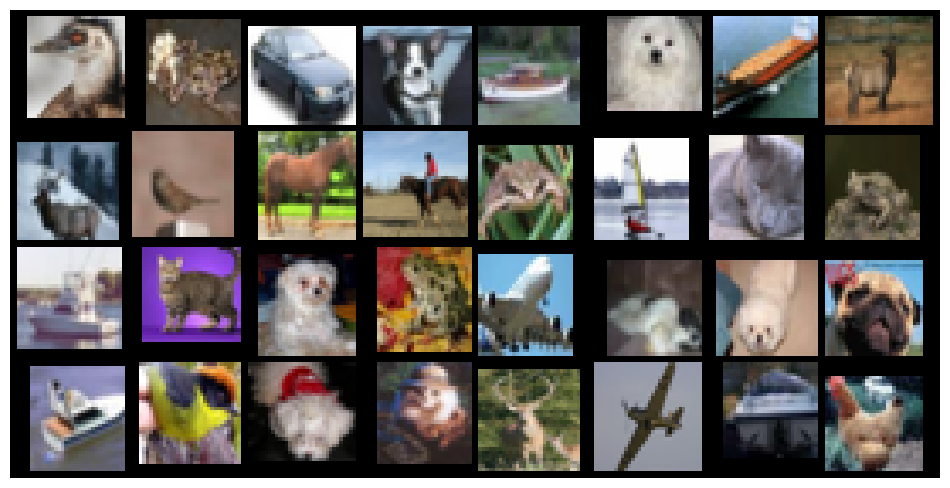

In [44]:
plt.figure(figsize=(12,12))
if grid.shape[0] == 1:
    plt.imshow(grid.squeeze(0), cmap="gray")
else:
    plt.imshow(grid.permute(1, 2, 0).clamp(0,1))
plt.axis("off")
plt.show()

In [45]:
print("İlk 10 görüntünün: ", [classes[int(y)] for y in y[:32]] )

İlk 10 görüntünün:  ['bird', 'frog', 'automobile', 'dog', 'ship', 'dog', 'ship', 'deer', 'deer', 'bird', 'horse', 'horse', 'frog', 'ship', 'cat', 'frog', 'ship', 'cat', 'dog', 'frog', 'airplane', 'dog', 'dog', 'dog', 'ship', 'bird', 'dog', 'cat', 'deer', 'airplane', 'ship', 'bird']


 ### Model Training

In [51]:
from importlib import reload
import SmallModel
reload(SmallModel)
from SmallModel import SmallCifarNet

model = SmallCifarNet(num_classes = len(classes)).to(device)
model

SmallCifarNet(
  (Block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
  )
  (Block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inpl

In [58]:
import torch.nn as nn 
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr =1e-3, weight_decay = 1e-4)

In [59]:
def train(model, dataloader, criterion, optimizer, device):

    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad() #gradyanları sıfırladık
        logits = model(xb) #görüntüleri modele verdik
        loss = criterion(logits, yb)

        loss.backward() #gradyan hesaplama yapılır geriye yayılım * autograd
        optimizer.step() #ağırlıklar ve bias güncellenmesi

        total_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    
    return avg_loss, acc


In [60]:
@torch.no_grad()
def evaluate(model,dataloader, criterion, device):
    
    model.eval()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in dataloader:
        xb , yb = xb.to(device), yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc


In [61]:
epochs = 30
file_path = "small_cifar_net.pt"

for epoch in range(1, epochs + 1):

    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)

    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch:02d}: Train Loss {train_loss*100:.2f}, Train Acc {train_acc*100:.2f}, Val Loss {val_loss*100:.2f}, Val Acc {val_acc*100:.2f}")

    torch.save({
        "model_state": model.state_dict(),
        "epoch":epoch,
        "mean": mean,
        "std": std,
        "classes":  classes,
        "arch": "SmallCifarNet"
    }, file_path)

Epoch 01: Train Loss 174.77, Train Acc 35.01, Val Loss 150.59, Val Acc 46.96
Epoch 02: Train Loss 128.87, Train Acc 52.97, Val Loss 110.94, Val Acc 59.68
Epoch 03: Train Loss 109.03, Train Acc 61.12, Val Loss 94.53, Val Acc 65.98
Epoch 04: Train Loss 97.17, Train Acc 65.76, Val Loss 82.23, Val Acc 70.34
Epoch 05: Train Loss 88.31, Train Acc 69.02, Val Loss 74.60, Val Acc 73.22
Epoch 06: Train Loss 81.43, Train Acc 71.81, Val Loss 68.40, Val Acc 77.12
Epoch 07: Train Loss 76.13, Train Acc 73.92, Val Loss 64.82, Val Acc 77.18
Epoch 08: Train Loss 71.95, Train Acc 75.36, Val Loss 67.94, Val Acc 76.14
Epoch 09: Train Loss 67.10, Train Acc 77.26, Val Loss 57.65, Val Acc 79.66
Epoch 10: Train Loss 63.74, Train Acc 78.13, Val Loss 60.64, Val Acc 79.30
Epoch 11: Train Loss 60.52, Train Acc 79.51, Val Loss 50.70, Val Acc 82.66
Epoch 12: Train Loss 58.44, Train Acc 80.29, Val Loss 55.94, Val Acc 82.06
Epoch 13: Train Loss 55.82, Train Acc 81.11, Val Loss 49.74, Val Acc 82.80
Epoch 14: Train Loss